---
## Step 0: Environment Setup & Imports

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import gzip
import json
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime
import h5py

warnings.filterwarnings('ignore')
sc.settings.verbosity = 2

# mirCCC pipeline
sys.path.insert(0, "./")  # 改这里
from mirCCC_integrated_pipeline_api import (
    Config, run_full_pipeline, setup_output_dirs, TORCH_AVAILABLE,
    compute_mirna_proxy, compute_sender_receiver_scores,
    build_communication_graph, MiRNATargetDatabase,
    unify_anndata_varnames,
    edges_to_mirna_edge_df, aggregate_to_cellpair_df,
    export_communication_results,
    run_pipeline_on_real_data  # 加这个，后面用到
)

print(f"PyTorch available: {TORCH_AVAILABLE}")
if TORCH_AVAILABLE:
    import torch
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch available: True
CUDA available: True
GPU: NVIDIA GeForce RTX 3090
GPU Memory: 25.4 GB


In [2]:
# === File Paths ===
# CRC scRNA-seq data (Pelka et al. 2021, GSE178341)
DATA_DIR = "./data/"
H5_PATH = os.path.join(DATA_DIR, "GSE178341_crc10x_full_c295v4_submit.h5")
CLUSTER_PATH = os.path.join(DATA_DIR, "GSE178341_crc10x_full_c295v4_submit_cluster.csv.gz")
META_PATH = os.path.join(DATA_DIR, "GSE178341_crc10x_full_c295v4_submit_metatables.csv.gz")

# miRNA reference data (included in repo)
MIRNA_DIR = "./mirna/"
MIR2TAR_PATH = os.path.join(MIRNA_DIR, "mir2tar.csv")
BIOGENESIS_PATH = os.path.join(MIRNA_DIR, "biogenesis.csv")
RISC_PATH = os.path.join(MIRNA_DIR, "risc.csv")
SORTING_PATH = os.path.join(MIRNA_DIR, "sorting.csv")
GENEINFO_PATH = os.path.join(MIRNA_DIR, "geneinfo.csv")

# Output
OUT_DIR = "./results/case_study_CRC/"
os.makedirs(OUT_DIR, exist_ok=True)

# Verify files exist
for p, name in [(H5_PATH, "H5"), (CLUSTER_PATH, "Cluster"), (META_PATH, "Meta"),
                (MIR2TAR_PATH, "mir2tar")]:
    exists = os.path.exists(p)
    size = os.path.getsize(p) / 1e6 if exists else 0
    print(f"  {name}: {'OK' if exists else 'MISSING'} ({size:.1f} MB)")

---
## Step 1: Load and Explore Data

In [3]:
# Load cluster and metadata

cluster_df = pd.read_csv(CLUSTER_PATH)
print(f"Cluster table: {cluster_df.shape}")
print(f"Columns: {cluster_df.columns.tolist()}")
print(f"\nFirst rows:")
display(cluster_df.head())

meta_df = pd.read_csv(META_PATH)
print(f"Meta table: {meta_df.shape}")
print(f"Columns: {meta_df.columns.tolist()}")
print(f"\nFirst rows:")
display(meta_df.head())

Cluster table: (370115, 6)
Columns: ['sampleID', 'batchID', 'clTopLevel', 'clMidwayPr', 'cl295v11SubShort', 'cl295v11SubFull']

First rows:


,sampleID,batchID,clTopLevel,clMidwayPr,cl295v11SubShort,cl295v11SubFull
0,C103_T_1_1_0_c1_v2_id-AAACCTGCATGCTAGT,C103_T_1_1_0_c1_v2,Epi,Epi,cE01,cE01 (Stem/TA-like)
1,C103_T_1_1_0_c1_v2_id-AAACCTGGTAGCCTAT,C103_T_1_1_0_c1_v2,Epi,Epi,cE01,cE01 (Stem/TA-like)
2,C103_T_1_1_0_c1_v2_id-AAACCTGGTTGTCGCG,C103_T_1_1_0_c1_v2,Epi,Epi,cE03,cE03 (Stem/TA-like prolif)
3,C103_T_1_1_0_c1_v2_id-AAACCTGTCATGTGGT,C103_T_1_1_0_c1_v2,Epi,Epi,cE01,cE01 (Stem/TA-like)
4,C103_T_1_1_0_c1_v2_id-AAACCTGTCCTTGGTC,C103_T_1_1_0_c1_v2,Epi,Epi,cE01,cE01 (Stem/TA-like)


Meta table: (370115, 27)
Columns: ['cellID', 'SPECIMEN_TYPE', 'SOURCE_HOSPITAL', 'TISSUE_PROCESSING_TEAM', 'PROCESSING_TYPE', 'SINGLECELL_TYPE', 'PatientTypeID', 'HistologicTypeSimple', 'MMR_IHC', 'MMRStatus', 'MLH1Status', 'MMRMLH1Tumor', 'TissueSite_detailed', 'TissueSiteSimple', 'HistologicGrade_detailed', 'HistologicGradeSimple', 'TumorStage', 'NodeStatus_detailed', 'NodeStatusSimple', 'MetastasisStatus', 'TumorSize', 'SizeQuantile', 'PID', 'Sex', 'Age', 'Ethnicity', 'Race']

First rows:


,cellID,SPECIMEN_TYPE,SOURCE_HOSPITAL,TISSUE_PROCESSING_TEAM,PROCESSING_TYPE,SINGLECELL_TYPE,PatientTypeID,HistologicTypeSimple,MMR_IHC,MMRStatus,...,NodeStatus_detailed,NodeStatusSimple,MetastasisStatus,TumorSize,SizeQuantile,PID,Sex,Age,Ethnicity,Race
0,C103_T_1_1_0_c1_v2_id-AAACCTGCATGCTAGT,T,MGH,Hacohen,unsorted,SC3Pv2,C103_T,Adenocarcinoma,preserved,MMRp,...,N0,Nneg,not entered (Mx),2.5,1.0,C103,M,45,No,Asian
1,C103_T_1_1_0_c1_v2_id-AAACCTGGTAGCCTAT,T,MGH,Hacohen,unsorted,SC3Pv2,C103_T,Adenocarcinoma,preserved,MMRp,...,N0,Nneg,not entered (Mx),2.5,1.0,C103,M,45,No,Asian
2,C103_T_1_1_0_c1_v2_id-AAACCTGGTTGTCGCG,T,MGH,Hacohen,unsorted,SC3Pv2,C103_T,Adenocarcinoma,preserved,MMRp,...,N0,Nneg,not entered (Mx),2.5,1.0,C103,M,45,No,Asian
3,C103_T_1_1_0_c1_v2_id-AAACCTGTCATGTGGT,T,MGH,Hacohen,unsorted,SC3Pv2,C103_T,Adenocarcinoma,preserved,MMRp,...,N0,Nneg,not entered (Mx),2.5,1.0,C103,M,45,No,Asian
4,C103_T_1_1_0_c1_v2_id-AAACCTGTCCTTGGTC,T,MGH,Hacohen,unsorted,SC3Pv2,C103_T,Adenocarcinoma,preserved,MMRp,...,N0,Nneg,not entered (Mx),2.5,1.0,C103,M,45,No,Asian


In [4]:
# Load expression matrix from 10x HDF5

with h5py.File(H5_PATH, "r") as f:
    group = f["matrix"] if "matrix" in f else list(f.values())[0]
    
    barcodes = [b.decode() if isinstance(b, bytes) else b for b in group["barcodes"][:]]
    gene_names = [g.decode() if isinstance(g, bytes) else g for g in group["features/name"][:]]
    
    data = group["data"][:]
    indices = group["indices"][:]
    indptr = group["indptr"][:]
    shape = group["shape"][:]
    
    X_sparse = sp.csc_matrix((data, indices, indptr), shape=shape).T

print(f"Expression matrix: {X_sparse.shape} (cells × genes)")
print(f"Barcodes: {len(barcodes)}, Genes: {len(gene_names)}")

  matrix/barcodes: (370115,) |S39
  matrix/data: (764460511,) float64
  matrix/features/_all_tag_keys: (1,) |S6
  matrix/features/feature_type: (43113,) |S15
  matrix/features/genome: (43113,) |S19
  matrix/features/id: (43113,) |S26
  matrix/features/name: (43113,) |S19
  matrix/indices: (764460511,) int32
  matrix/indptr: (370116,) int32
  matrix/shape: (2,) int32
X_sparse: (370115, 43113)  (cells × genes)
Barcodes: 370115, Genes: 43113


---
## Step 2: Build AnnData & Select Patient Subset

Select patient C162 (MMRp) — the largest sample in the dataset with balanced representation of all 7 major cell lineages (Epi, Myeloid, Strom, TNKILC, B, Plasma, Mast).

In [5]:
# Build the full AnnData object
adata_full = ad.AnnData(
    X=X_sparse,
    obs=pd.DataFrame(index=barcodes),
    var=pd.DataFrame(index=gene_names)
)
adata_full.var_names_make_unique()
print(f"Full AnnData: {adata_full.shape}")

# Merge cluster info
if cluster_df.columns[0] in ['', 'Unnamed: 0', 'barcode', 'cell', 'cellID']:
    cluster_df = cluster_df.set_index(cluster_df.columns[0])
elif cluster_df.index.dtype == 'int64' and len(cluster_df) == len(barcodes):
    cluster_df.index = barcodes

common = adata_full.obs.index.intersection(cluster_df.index)
if len(common) > 0:
    print(f"Matched {len(common)} / {adata_full.n_obs} cells to cluster annotations")
    for col in cluster_df.columns:
        adata_full.obs[col] = cluster_df.loc[adata_full.obs_names, col].values
else:
    print(f"WARNING: No direct barcode match. Trying positional alignment...")
    if len(cluster_df) == adata_full.n_obs:
        for col in cluster_df.columns:
            adata_full.obs[col] = cluster_df[col].values
        print(f"Positional alignment successful.")
    else:
        print(f"Cluster rows ({len(cluster_df)}) != cells ({adata_full.n_obs})")

# Merge meta info
meta_df = meta_df.set_index("cellID")
common_meta = adata_full.obs.index.intersection(meta_df.index)
print(f"Matched {len(common_meta)} / {adata_full.n_obs} cells to meta annotations")
for col in meta_df.columns:
    if col not in adata_full.obs.columns:
        adata_full.obs[col] = meta_df.loc[adata_full.obs_names, col].values

print(f"\nobs columns: {adata_full.obs.columns.tolist()}")

Full AnnData: (370115, 43113)
Matched 370115 / 370115 cells to cluster annotations
Matched 370115 / 370115 cells to meta annotations

obs columns: ['sampleID', 'batchID', 'clTopLevel', 'clMidwayPr', 'cl295v11SubShort', 'cl295v11SubFull', 'SPECIMEN_TYPE', 'SOURCE_HOSPITAL', 'TISSUE_PROCESSING_TEAM', 'PROCESSING_TYPE', 'SINGLECELL_TYPE', 'PatientTypeID', 'HistologicTypeSimple', 'MMR_IHC', 'MMRStatus', 'MLH1Status', 'MMRMLH1Tumor', 'TissueSite_detailed', 'TissueSiteSimple', 'HistologicGrade_detailed', 'HistologicGradeSimple', 'TumorStage', 'NodeStatus_detailed', 'NodeStatusSimple', 'MetastasisStatus', 'TumorSize', 'SizeQuantile', 'PID', 'Sex', 'Age', 'Ethnicity', 'Race']


In [6]:
# Identify cell type and patient columns
print("Available annotation columns:")
for col in adata_full.obs.columns:
    n_unique = adata_full.obs[col].nunique()
    if n_unique <= 20:
        print(f"  {col}: {n_unique} unique — {adata_full.obs[col].unique().tolist()}")
    elif n_unique <= 100:
        print(f"  {col}: {n_unique} unique — (too many to list)")
    else:
        print(f"  {col}: {n_unique} unique")

Available annotation columns:
  sampleID: 370115 unique
  batchID: 180 unique
  clTopLevel: 7 unique — ['Epi', 'TNKILC', 'Strom', 'Myeloid', 'B', 'Mast', 'Plasma']
  clMidwayPr: 19 unique — ['Epi', 'TCD4', 'Peri', 'Macro', 'DC', 'NK', 'Endo', 'Mono', 'Fibro', 'TCD8', 'B', 'Mast', 'Plasma', 'TZBTB16', 'Tgd', 'Granulo', 'ILC', 'SmoothMuscle', 'Schwann']
  cl295v11SubShort: 87 unique — (too many to list)
  cl295v11SubFull: 87 unique — (too many to list)
  SPECIMEN_TYPE: 2 unique — ['T', 'N']
  SOURCE_HOSPITAL: 2 unique — ['MGH', 'DFCI']
  TISSUE_PROCESSING_TEAM: 4 unique — ['Hacohen', 'CCPM_Hacohen', 'Combined', 'CCPM_Regev']
  PROCESSING_TYPE: 4 unique — ['unsorted', 'LiveMACS', 'CD45pMACS', 'mixUnsortCD45MACS']
  SINGLECELL_TYPE: 2 unique — ['SC3Pv2', 'SC3Pv3']
  PatientTypeID: 100 unique — (too many to list)
  HistologicTypeSimple: 6 unique — ['Adenocarcinoma', 'Normal colon', 'Adenocarcinoma;Mucinous', 'Adenocarcinoma;Medullary (with solid growth pattern)', 'Adenocarcinoma;Mucinous;Ne

In [7]:
# Define cell type mapping
# Typical Pelka columns: 'clTopLevel' (7 lineages), 'cl295v11SubFull' (detailed)

CELLTYPE_COL = None
PATIENT_COL = None

for col in adata_full.obs.columns:
    n = adata_full.obs[col].nunique()
    col_lower = col.lower()
    
    # Cell type: look for 5-15 unique values typical of major lineages
    if CELLTYPE_COL is None and 5 <= n <= 15:
        vals_lower = set(str(v).lower() for v in adata_full.obs[col].unique())
        if any(k in ' '.join(vals_lower) for k in ['tumor', 'malig', 'macro', 'tcell', 't cell', 
                                                     'myeloid', 'stromal', 'epithelial']):
            CELLTYPE_COL = col
    
    # Patient: look for column with 20-70 unique values
    if PATIENT_COL is None and 20 <= n <= 100:
        if any(k in col_lower for k in ['patient', 'sample', 'donor', 'subject', 'id']):
            PATIENT_COL = col

# Fallback: use first column with appropriate cardinality
if CELLTYPE_COL is None:
    for col in adata_full.obs.columns:
        if 5 <= adata_full.obs[col].nunique() <= 20:
            CELLTYPE_COL = col
            break

print(f"Cell type column: {CELLTYPE_COL}")
print(f"Patient column: {PATIENT_COL}")

if CELLTYPE_COL:
    print(f"\nCell type distribution:")
    print(adata_full.obs[CELLTYPE_COL].value_counts())

Cell type column: clTopLevel
Patient column: PatientTypeID

Cell type distribution:
clTopLevel
Epi        168295
TNKILC      76965
Myeloid     42114
Plasma      37809
B           25660
Strom       15438
Mast         3834
Name: count, dtype: int64


In [8]:
# Patient selection — find MMRd patients with rich immune infiltrate
PATIENT_COL = "PID"
CELLTYPE_COL = "clTopLevel"  # 或者用更细的 "cl295v11SubFull"

if PATIENT_COL is not None:
    print("Per-patient cell counts and type composition:")
    patient_stats = []
    
    for patient in adata_full.obs[PATIENT_COL].unique():
        mask = adata_full.obs[PATIENT_COL] == patient
        n_cells = mask.sum()
        if CELLTYPE_COL:
            ct_counts = adata_full.obs.loc[mask, CELLTYPE_COL].value_counts().to_dict()
            n_types = len(ct_counts)
        else:
            ct_counts = {}
            n_types = 0
        
        patient_stats.append({
            'patient': patient,
            'n_cells': n_cells,
            'n_types': n_types,
            **ct_counts
        })
    
    patient_df = pd.DataFrame(patient_stats).sort_values('n_cells', ascending=False)
    display(patient_df.head(20))
else:
    print("No patient column found. Will use full dataset or random subsample.")
    patient_df = None

Per-patient cell counts and type composition:


,patient,n_cells,n_types,Epi,TNKILC,Myeloid,Strom,Plasma,B,Mast
50,C162,22587,7,9379,3054,2721,2058,2741.0,2317,317.0
17,C124,16945,7,8834,2189,2155,881,1236.0,1205,445.0
59,C171,16199,7,4865,3024,622,236,7029.0,355,68.0
16,C123,14572,7,6456,3622,1461,322,1622.0,990,99.0
19,C126,12914,7,5010,1254,1231,674,4378.0,197,170.0
18,C125,12660,7,6071,2091,1422,711,1102.0,1104,159.0
20,C129,12577,7,4131,2239,643,219,3085.0,2133,127.0
58,C170,12522,7,3932,2577,3238,698,67.0,1941,69.0
21,C130,11327,7,5294,2787,897,262,1094.0,717,276.0
29,C139,10468,7,4579,2032,607,311,1371.0,1404,164.0


In [9]:
# Subset to selected patient(s)
# Strategy: Pick patient(s) with 5000–10000 cells AND good cell type diversity
# Prefer patients with macrophages + T cells + fibroblasts + endothelial

TARGET_CELLS = 8000  # target cell count for subsetting

if patient_df is not None and PATIENT_COL is not None:
    # Score patients by: (n_cells in range) * (n_types diversity)
    patient_df['score'] = patient_df['n_types'] * np.minimum(patient_df['n_cells'], TARGET_CELLS)
    
    # Pick the best patient
    best_patients = patient_df.sort_values('score', ascending=False).head(5)
    print("Top 5 candidate patients:")
    display(best_patients[['patient', 'n_cells', 'n_types', 'score']])
    
    SELECTED_PATIENT = best_patients.iloc[0]['patient']
    print(f"\n→ Selected patient: {SELECTED_PATIENT}")
    
    # Subset
    mask = adata_full.obs[PATIENT_COL] == SELECTED_PATIENT
    adata = adata_full[mask].copy()
else:
    # No patient column: random subsample
    print(f"Subsampling {TARGET_CELLS} cells from full dataset...")
    if adata_full.n_obs > TARGET_CELLS:
        sc.pp.subsample(adata_full, n_obs=TARGET_CELLS, random_state=42)
    adata = adata_full.copy()

print(f"\nSubset AnnData: {adata.shape}")
if CELLTYPE_COL and CELLTYPE_COL in adata.obs.columns:
    print(f"Cell type distribution in subset:")
    print(adata.obs[CELLTYPE_COL].value_counts())

Top 5 candidate patients:


,patient,n_cells,n_types,score
50,C162,22587,7,56000
17,C124,16945,7,56000
59,C171,16199,7,56000
16,C123,14572,7,56000
19,C126,12914,7,56000



→ Selected patient: C162

Subset AnnData: (22587, 43113)
Cell type distribution in subset:
clTopLevel
Epi        9379
TNKILC     3054
Plasma     2741
Myeloid    2721
B          2317
Strom      2058
Mast        317
Name: count, dtype: int64


In [10]:
# Filter tumor tissue only
print(f"Before filtering: {adata.shape}")
print(f"Specimen types: {adata.obs['SPECIMEN_TYPE'].value_counts().to_dict()}")

adata = adata[adata.obs['SPECIMEN_TYPE'] == 'T'].copy()

print(f"After tumor filter: {adata.shape}")
print(f"Cell types:\n{adata.obs[CELLTYPE_COL].value_counts()}")

Before filtering: (22587, 43113)
Specimen types: {'T': 15861, 'N': 6726}
After tumor filter: (15861, 43113)
Cell types:
clTopLevel
Epi        8406
Myeloid    2448
Strom      1581
TNKILC     1321
B           972
Plasma      908
Mast        225
Name: count, dtype: int64


In [11]:
# Further subsample while preserving cell type proportions
MAX_CELLS = 10000
np.random.seed(42)

if adata.n_obs > MAX_CELLS:
    print(f"Dataset has {adata.n_obs} cells, subsampling to {MAX_CELLS}...")
    
    if CELLTYPE_COL and CELLTYPE_COL in adata.obs.columns:
        # Stratified subsampling
        frac = MAX_CELLS / adata.n_obs
        keep_idx = []
        for ct in adata.obs[CELLTYPE_COL].unique():
            ct_idx = np.where(adata.obs[CELLTYPE_COL] == ct)[0]
            n_keep = max(10, int(len(ct_idx) * frac))  # at least 10 per type
            n_keep = min(n_keep, len(ct_idx))
            keep_idx.extend(np.random.choice(ct_idx, n_keep, replace=False))
        
        adata = adata[sorted(keep_idx)].copy()
    else:
        sc.pp.subsample(adata, n_obs=MAX_CELLS, random_state=42)
    
    print(f"After subsampling: {adata.shape}")
    if CELLTYPE_COL:
        print(adata.obs[CELLTYPE_COL].value_counts())

Dataset has 15861 cells, subsampling to 10000...
After subsampling: (9995, 43113)
clTopLevel
Epi        5299
Myeloid    1543
Strom       996
TNKILC      832
B           612
Plasma      572
Mast        141
Name: count, dtype: int64


In [12]:
adata.obs['cell_type'] = adata.obs['clTopLevel'].copy()
print("Cell type distribution:")
print(adata.obs['cell_type'].value_counts())

Cell type distribution:
cell_type
Epi        5299
Myeloid    1543
Strom       996
TNKILC      832
B           612
Plasma      572
Mast        141
Name: count, dtype: int64


---
## Step 3: Quality Control & Preprocessing

In [13]:
# Basic QC
adata.layers['counts'] = adata.X.copy()

sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)

print(f"\nQC Summary:")
print(f"  Genes per cell: median={adata.obs['n_genes_by_counts'].median():.0f}, mean={adata.obs['n_genes_by_counts'].mean():.0f}")
print(f"  Counts per cell: median={adata.obs['total_counts'].median():.0f}, mean={adata.obs['total_counts'].mean():.0f}")

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=10)
print(f"\nPost-QC shape: {adata.shape}")


QC Summary:
  Genes per cell: median=2325, mean=2888
  Counts per cell: median=9814, mean=19912
filtered out 23034 genes that are detected in less than 10 cells

Post-QC shape: (9995, 20079)


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:21)
computing UMAP
    finished (0:00:15)


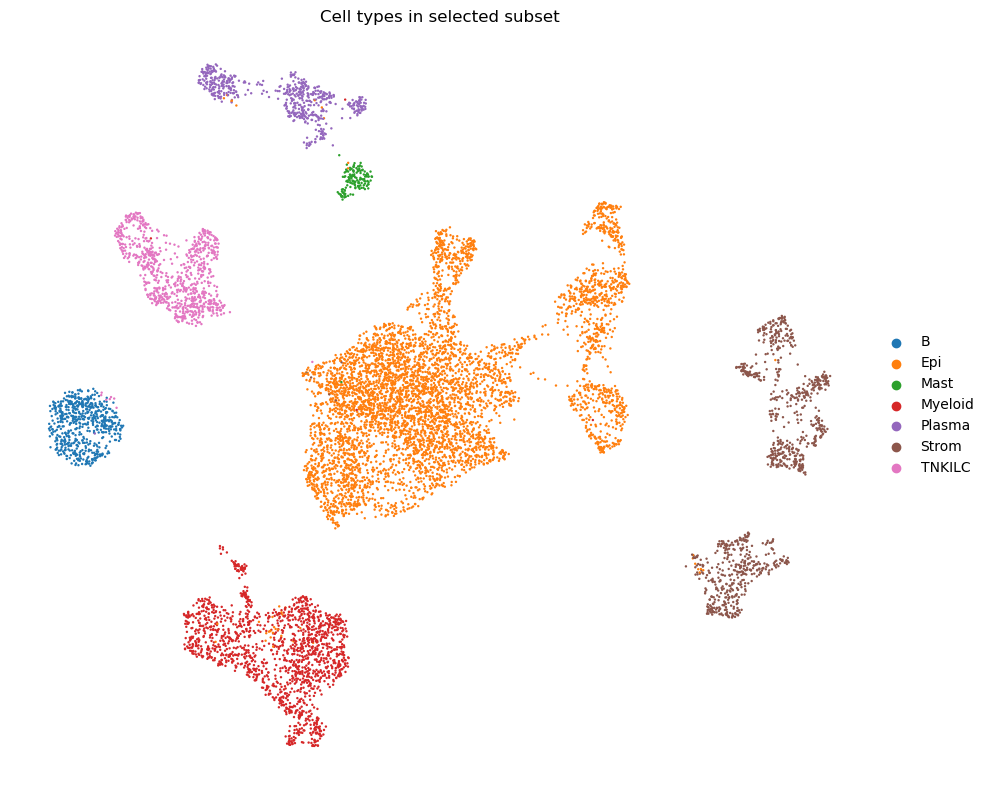

In [14]:
# Compute UMAP for visualization
adata_viz = adata.copy()
sc.pp.normalize_total(adata_viz, target_sum=1e4)
sc.pp.log1p(adata_viz)
sc.pp.highly_variable_genes(adata_viz, n_top_genes=2000)
sc.tl.pca(adata_viz, n_comps=50)
sc.pp.neighbors(adata_viz, n_pcs=30)
sc.tl.umap(adata_viz)

# Store UMAP coords in main adata
adata.obsm['X_umap'] = adata_viz.obsm['X_umap']

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
sc.pl.umap(adata, color='cell_type', ax=ax, show=False, 
           title='Cell types in selected subset', frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'umap_cell_types.png'), dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Check presence of miRNA machinery genes
var_set = set(adata.var_names.str.upper())

for name, path in [('Biogenesis', BIOGENESIS_PATH), ('RISC', RISC_PATH), ('Sorting', SORTING_PATH)]:
    if os.path.exists(path):
        df_tmp = pd.read_csv(path)
        if 'species' in df_tmp.columns:
            df_tmp = df_tmp[df_tmp['species'].str.lower() == 'human']
        genes = set(df_tmp['gene'].astype(str).str.upper())
        overlap = genes & var_set
        print(f"  {name}: {len(overlap)}/{len(genes)} found ({len(overlap)/len(genes)*100:.0f}%)")
        if len(overlap) < len(genes):
            missing = genes - var_set
            print(f"    Missing: {sorted(missing)[:10]}...")

# Check target genes coverage
mir2tar_df = pd.read_csv(MIR2TAR_PATH)
mir2tar_human = mir2tar_df[mir2tar_df['species'].astype(str).str.lower() == 'human']
all_targets = set(mir2tar_human['target_gene'].astype(str).str.upper())
target_overlap = all_targets & var_set
print(f"\n  miRNA targets: {len(target_overlap)}/{len(all_targets)} found ({len(target_overlap)/len(all_targets)*100:.0f}%)")

  Biogenesis: 50/61 found (82%)
    Missing: ['ALIX', 'CD10', 'CHMP1', 'FAN', 'HSC70', 'HSPA8 ', 'KIBRA', 'LAMP2A', 'LC3B', 'STAM1']...
  RISC: 20/23 found (87%)
    Missing: ['CAF1', 'DCP1', 'GW182']...
  Sorting: 6/8 found (75%)
    Missing: ['HUR', 'NSAP1']...

  miRNA targets: 14823/18874 found (79%)


---
## Step 4: Run mirCCC Pipeline

In [16]:
# Configure mirCCC for real data

cfg = Config()
cfg.OUTPUT_DIR = os.path.join(OUT_DIR, "mirage_run")
cfg.MIR2TAR_PATH = MIR2TAR_PATH
cfg.BIOGENESIS_PATH = BIOGENESIS_PATH
cfg.RISC_PATH = RISC_PATH
cfg.SORTING_PATH = SORTING_PATH
cfg.GENEINFO_PATH = GENEINFO_PATH
cfg.SPECIES = 'Human'

# Device
cfg.DEVICE = 'cuda:2' if (TORCH_AVAILABLE and torch.cuda.is_available()) else 'cpu'

n_cells = adata.n_obs
print(f"Dataset size: {n_cells} cells")

MAX_MIRNAS = 50           # Only use top-50 miRNAs (ensures key validation ones are included)
cfg.TOP_S_SENDERS = min(800, n_cells // 4)   
cfg.TOP_R_RECEIVERS = min(800, n_cells // 4)
cfg.TOP_L_PER_SENDER = 10   
cfg.MIN_CELLS_EXPR = 5
cfg.MIN_TARGETS_PER_MIRNA = 10

# Estimate edge budget
est_edges = MAX_MIRNAS * cfg.TOP_S_SENDERS * cfg.TOP_L_PER_SENDER
print(f"\nEstimated max edges: {est_edges:,}")

# Training
cfg.NUM_EPOCHS = 300
cfg.HIDDEN_DIM = 128
cfg.NUM_HEADS = 4
cfg.LEARNING_RATE = 0.001

# Postprocessing
cfg.NUM_PARTS = 50
cfg.OVERLAP_HOPS = 1
cfg.RETAIN_PERCENT = 1.0

cfg.SAVE_FIGURES = False

setup_output_dirs(cfg)

print(f"\nConfig:")
print(f"  Device: {cfg.DEVICE}")
print(f"  TOP_S: {cfg.TOP_S_SENDERS}, TOP_R: {cfg.TOP_R_RECEIVERS}, TOP_L: {cfg.TOP_L_PER_SENDER}")
print(f"  MAX_MIRNAS: {MAX_MIRNAS}")
print(f"  Epochs: {cfg.NUM_EPOCHS}, Hidden: {cfg.HIDDEN_DIM}, Heads: {cfg.NUM_HEADS}")
print(f"  Estimated edges: {est_edges:,}")

Dataset size: 9995 cells

Estimated max edges: 400,000

Config:
  Device: cuda:2
  TOP_S: 800, TOP_R: 800, TOP_L: 10
  MAX_MIRNAS: 50
  Epochs: 300, Hidden: 128, Heads: 4
  Estimated edges: 400,000


In [45]:
mir2tar_full = pd.read_csv(MIR2TAR_PATH)
mir2tar_strong = mir2tar_full[mir2tar_full['support'] == 'Functional MTI']
STRONG_PATH = os.path.join(OUT_DIR, 'mir2tar_strong.csv')
mir2tar_strong.to_csv(STRONG_PATH, index=False)
print(f"Strong mir2tar: {len(mir2tar_strong)} records, {mir2tar_strong['miRNA'].nunique()} miRNAs")

cfg.MIR2TAR_PATH = STRONG_PATH

if 'counts' in adata.layers:
    adata.X = adata.layers['counts'].copy()

results = run_pipeline_on_real_data(adata, cfg, max_mirnas=200)

Strong mir2tar: 12731 records, 909 miRNAs

              mirCCC: miRNA-mediated Cell Communication
                    Real Data Analysis Pipeline

Started at: 2026-03-07 19:25:23
Input: 9995 cells × 20079 genes
Max miRNAs: 200

PHASE 0.5: Unifying Gene Names

  Unifying gene names...
  [alias-map] species=human | rows=72207 | unique=63421 | conflict_skipped=3599 | symbols=27302
  [unify] human: genes 20079 -> 19575 (merged 504)
  [clean_uns] Removed 'gene_alias_map' (h5py-incompatible keys)

STEP 1: Computing miRNA Proxy
  Filtered genes: 2451
  Filtered miRNAs: 180
  miRNAs with coverage >= 0: 180 / 180
  Proxy matrix shape: (9995, 180)
  Stored in adata.obsm['X_miRNA_proxy']

  miRNA count (180) <= max (200), no filtering needed.

STEP 2: Computing Sender/Receiver Scores
normalizing counts per cell
    finished (0:00:00)
  Biogenesis genes: 49 hit
  RISC genes: 20 hit
  Sorting genes: 5 hit
  Computed scores stored in adata.obs

  Saved adata with scores to: /home/YifanChen/mirCCC/e

Computing METIS partitioning...
Done!


    METIS created 50 partitions
    Generated 50 subgraphs with 1-hop overlap

STEP 5: Running Inference
  Processing 50 subgraphs...
    Subgraph 10/50
    Subgraph 20/50
    Subgraph 30/50
    Subgraph 40/50
    Subgraph 50/50
  Aggregating results...
  Embeddings saved to: /home/YifanChen/mirCCC/exp4_real_crc_validation_37/mirage_run/results/node_embeddings.pkl.gz
  Attention saved to: /home/YifanChen/mirCCC/exp4_real_crc_validation_37/mirage_run/results/edge_attention.pkl.gz

  Filtering top 100.0% edges...
    Kept 1439707 / 1439707 edges
    Saved to: /home/YifanChen/mirCCC/exp4_real_crc_validation_37/mirage_run/results/filtered_attention.pkl.gz

PHASE 5.5: Exporting Standardized Results

EXPORT: Standardized Communication Results

[1] Generating miRNA-level edge table...
  [edges_to_mirna_edge_df] Created DataFrame with 1439707 edges, 180 unique miRNAs
    Saved: /home/YifanChen/mirCCC/exp4_real_crc_validation_37/mirage_run/results/mirCCC_mirna_edges.csv

[2] Generating cell-pai

In [47]:
# Check key miRNAs in graph
payload = results['payload']
mirna_list = payload['mirna_list']
print(f"Total miRNAs in graph: {len(mirna_list)}")
print(f"Total edges: {payload['row_col'].shape[0]:,}")

KEY_PATTERNS = ['mir-21', 'mir-155', 'mir-25', 'mir-934',
                'mir-203', 'mir-92a', 'mir-106', 'mir-1246',
                'mir-130b', 'mir-425', 'mir-29a', 'mir-146a',
                'mir-150', 'mir-142', 'mir-223', 'mir-34a', 'mir-200c']

print(f"\nKey CRC miRNAs in graph:")
for pat in KEY_PATTERNS:
    matched = [m for m in mirna_list if matches_pattern(m, pat)]
    status = '✓' if matched else '✗'
    print(f"  {status} {pat}: {matched if matched else 'missing'}")

Total miRNAs in graph: 180
Total edges: 1,439,707

Key CRC miRNAs in graph:
  ✓ mir-21: ['mir-21']
  ✓ mir-155: ['mir-155']
  ✓ mir-25: ['mir-25']
  ✗ mir-934: missing
  ✓ mir-203: ['mir-203a']
  ✓ mir-92a: ['mir-92a']
  ✓ mir-106: ['mir-106a', 'mir-106b']
  ✗ mir-1246: missing
  ✓ mir-130b: ['mir-130b']
  ✗ mir-425: missing
  ✓ mir-29a: ['mir-29a']
  ✓ mir-146a: ['mir-146a']
  ✓ mir-150: ['mir-150']
  ✓ mir-142: ['mir-142']
  ✓ mir-223: ['mir-223']
  ✓ mir-34a: ['mir-34a']
  ✓ mir-200c: ['mir-200c']


---
## Step 5: Visualization

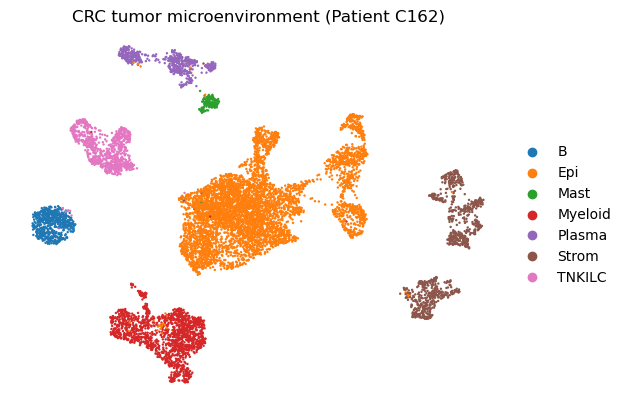

<Figure size 640x480 with 0 Axes>

In [67]:
import scanpy as sc

if 'X_umap' not in adata.obsm:
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

sc.pl.umap(adata, color='cell_type', 
           title='CRC tumor microenvironment (Patient C162)',
           frameon=False, 
           save=False)
plt.savefig(os.path.join(OUT_DIR, 'umap_celltype.png'), dpi=300, bbox_inches='tight')
plt.show()

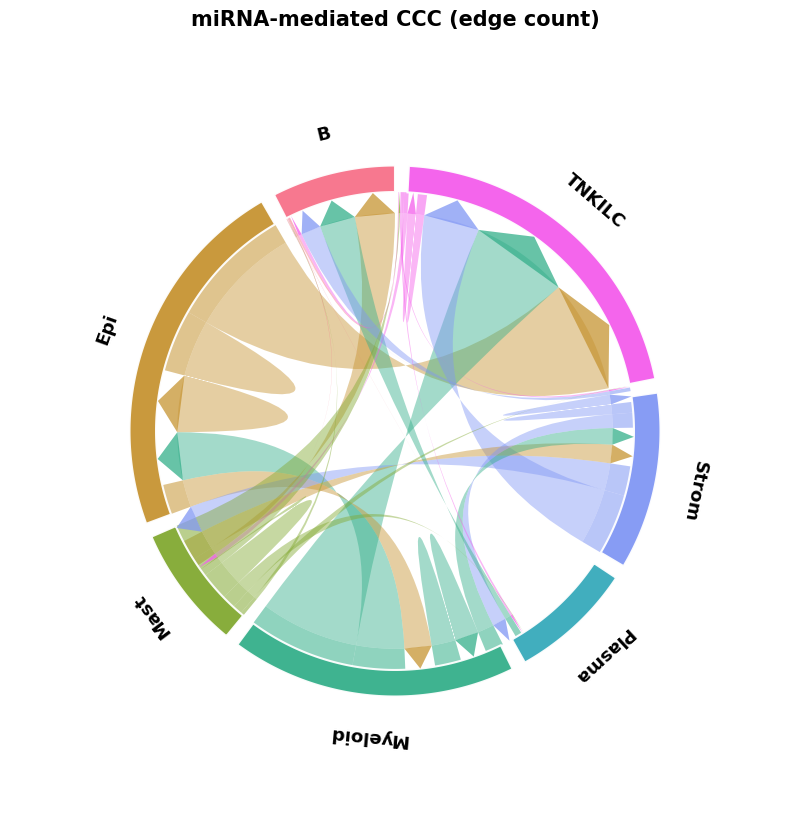

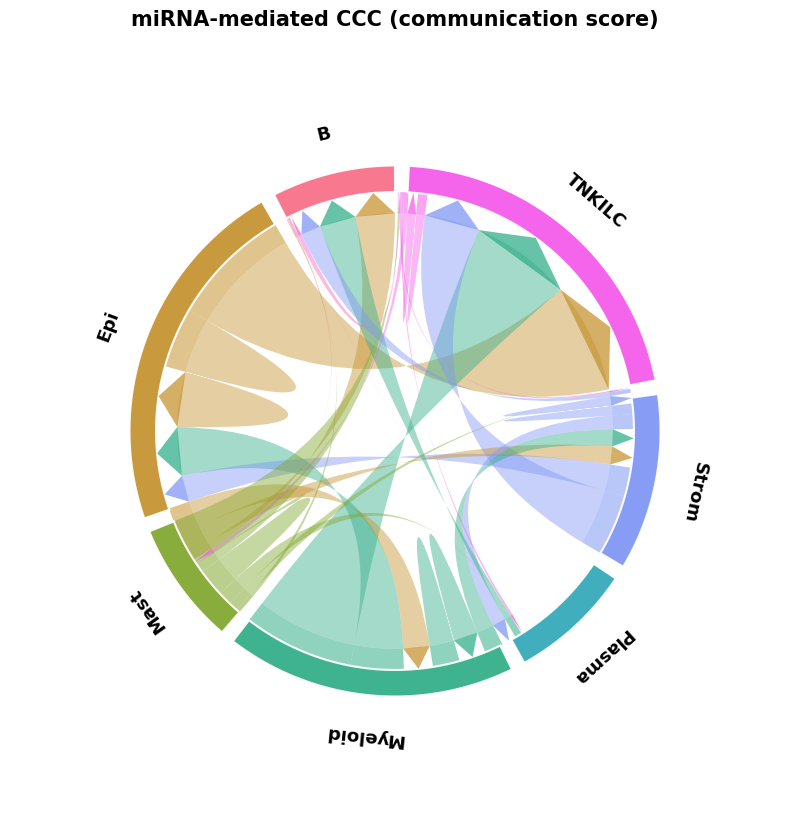

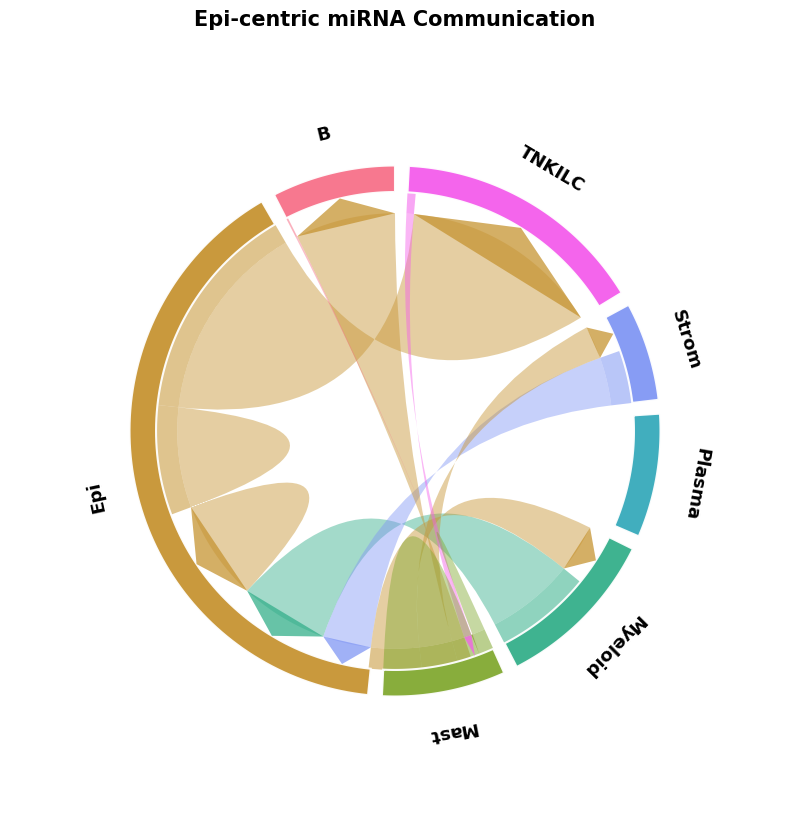

In [56]:
# Chord diagram — global communication network
from mirCCC_viz import plot_chord, plot_chord_focal

edge_df = results['mirna_edge_df']

plot_chord(edge_df, adata, value='count',
           title='miRNA-mediated CCC (edge count)',
           save_path=os.path.join(OUT_DIR, 'chord_number.png'))

plot_chord(edge_df, adata, value='score',
           title='miRNA-mediated CCC (communication score)',
           save_path=os.path.join(OUT_DIR, 'chord_score.png'))

plot_chord_focal(edge_df, adata, focal_celltype='Epi', value='score',
                 save_path=os.path.join(OUT_DIR, 'chord_Epi_focal.png'))

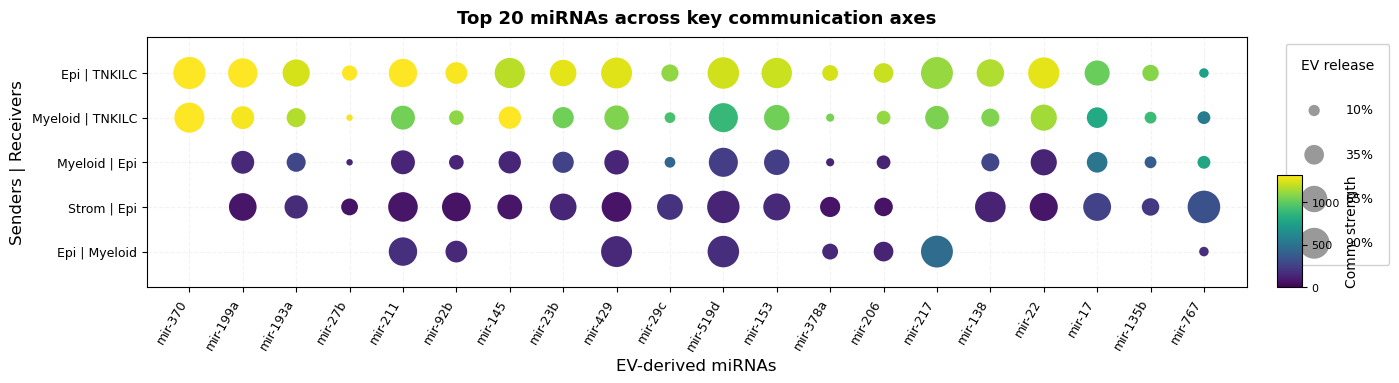

In [74]:
import mirCCC_viz
from mirCCC_viz import plot_dotplot

plot_dotplot(
    edge_focal, adata,
    proxy_matrix=PR,
    top_n_mirna=20,
    title='Top 20 miRNAs across key communication axes',
    save_path=os.path.join(OUT_DIR, 'dotplot_focal_axes.png')
)

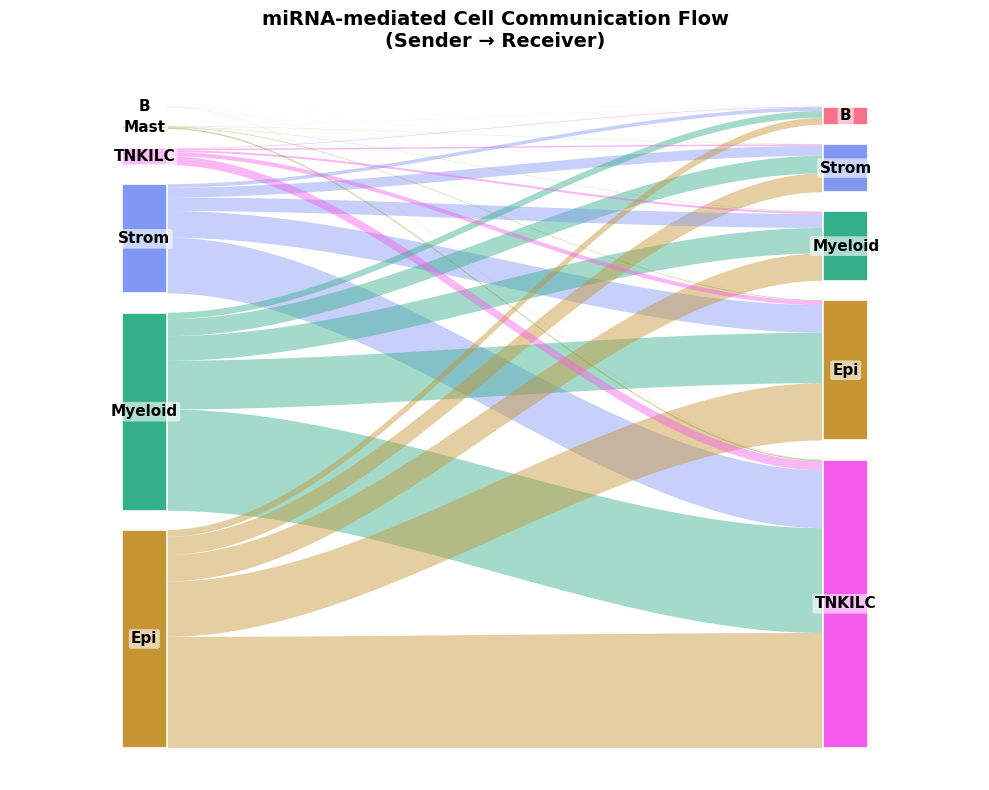

In [134]:
# Sankey diagram
import importlib, mirCCC_viz
importlib.reload(mirCCC_viz)
from mirCCC_viz import plot_sankey

plot_sankey(
    edge_df, adata,
    title='miRNA-mediated Cell Communication Flow\n(Sender → Receiver)',
    save_path=os.path.join(OUT_DIR, 'sankey_global.png'),
    figsize=(10, 8)
)

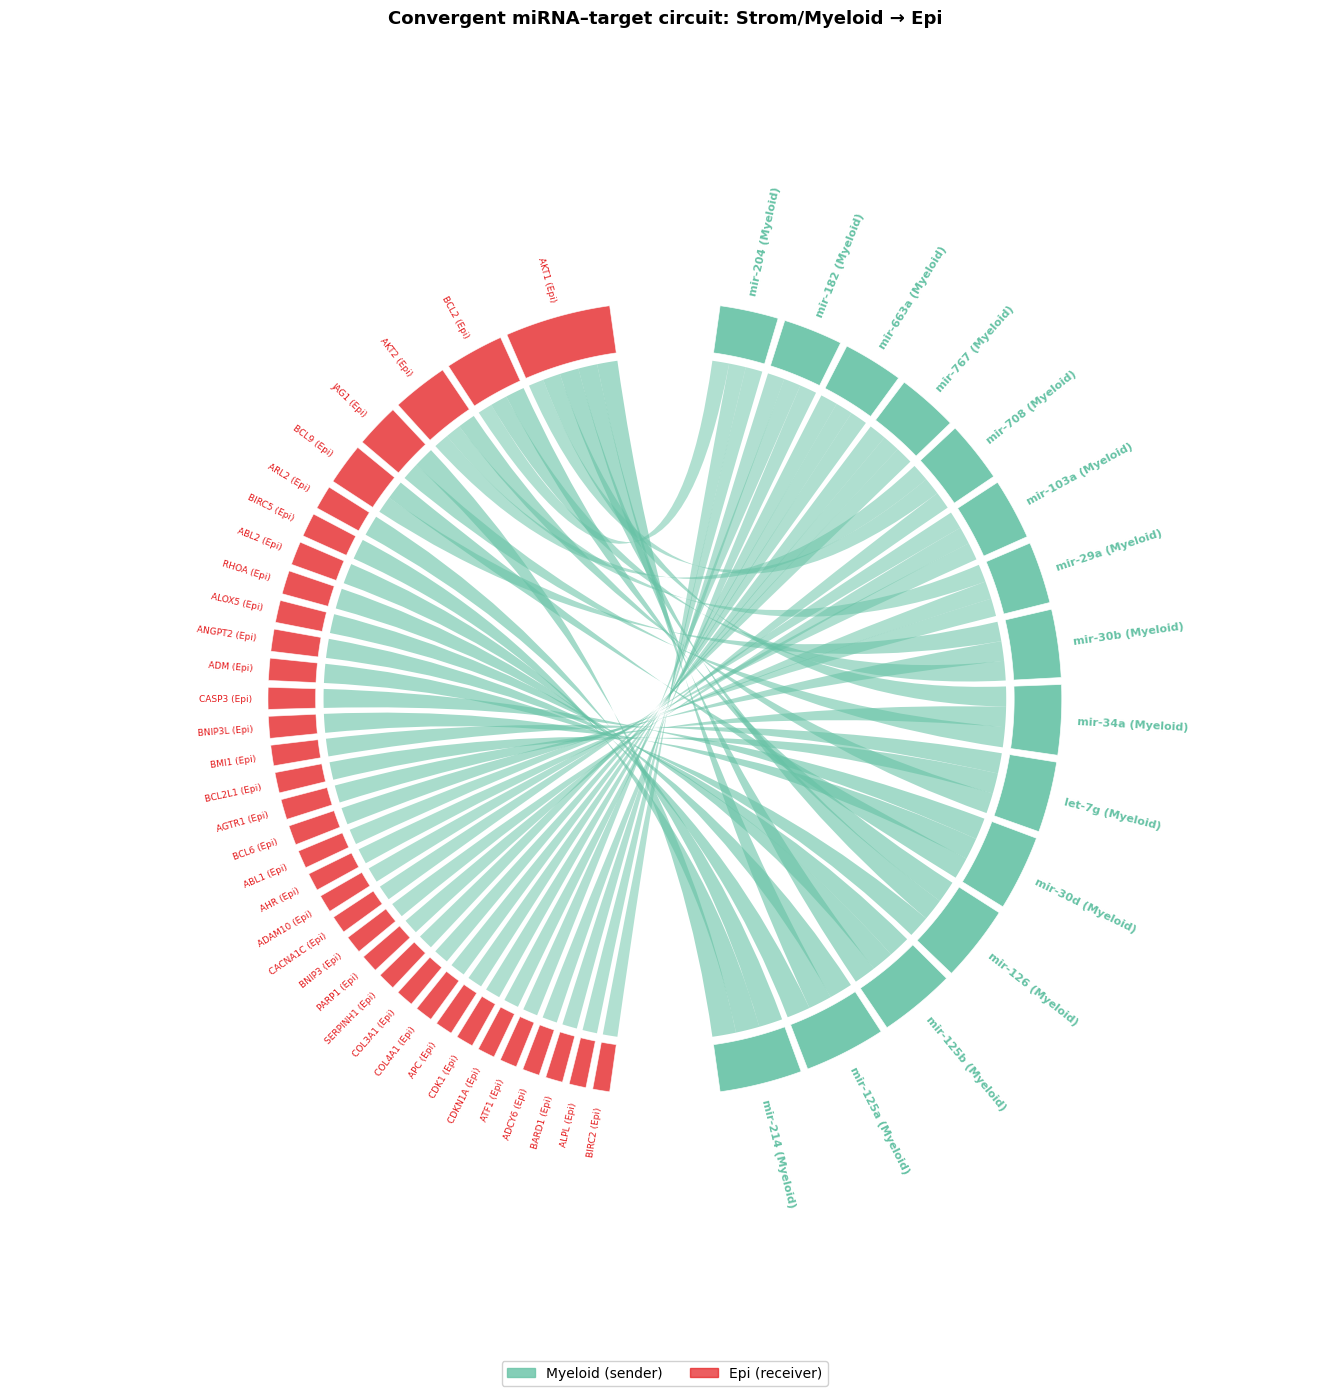

In [117]:
import importlib, mirCCC_viz
importlib.reload(mirCCC_viz)
from mirCCC_viz import plot_circos

edge_df = results['mirna_edge_df']
mir2tar_df = pd.read_csv(STRONG_PATH)

plot_circos(
    edge_df, adata, mir2tar_df,
    sender_types=['Strom', 'Myeloid'],
    receiver_types=['Epi'],
    top_n_mirna=15,
    top_n_target_per_mirna=3,
    title='Convergent miRNA–target circuit: Strom/Myeloid → Epi',
    save_path=os.path.join(OUT_DIR, 'circos_strom_myeloid_to_epi.png')
)

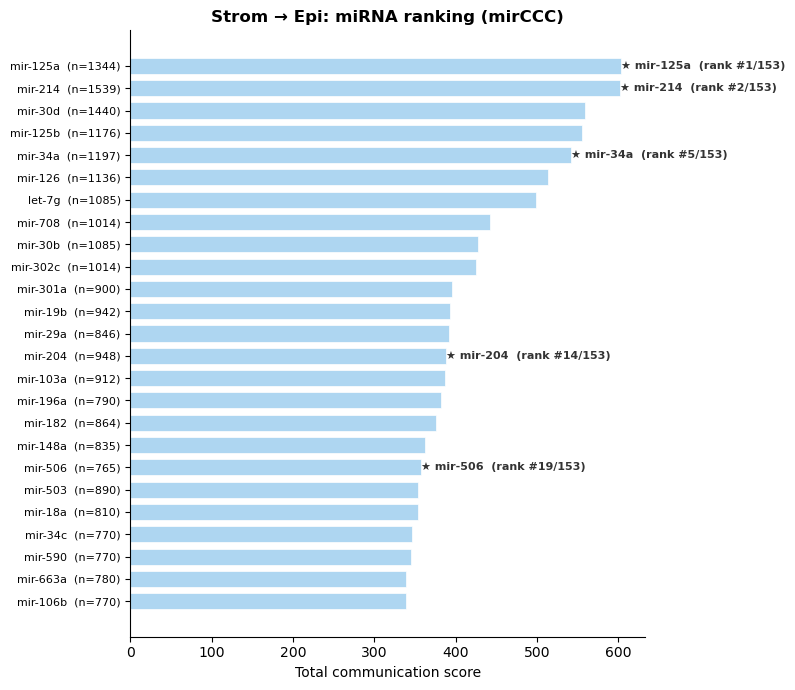

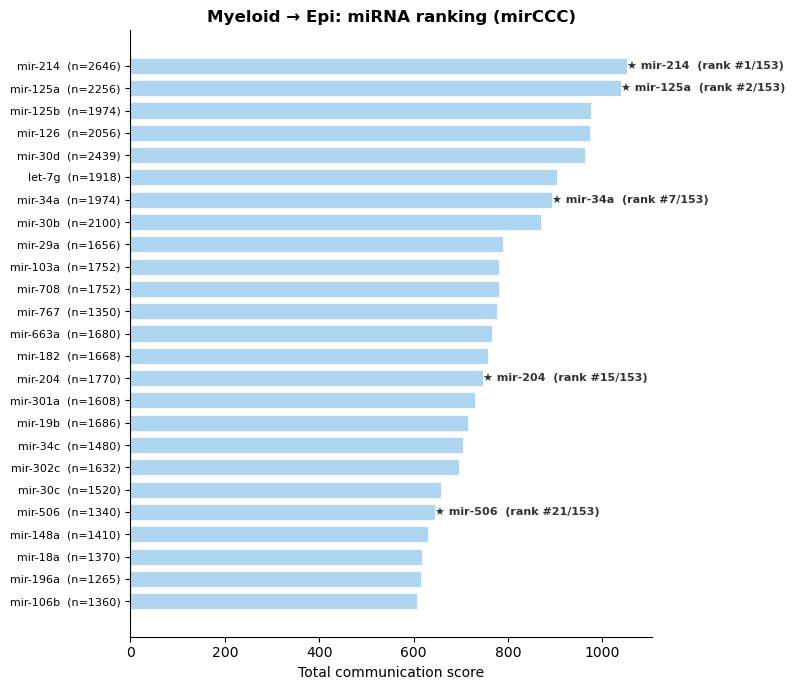

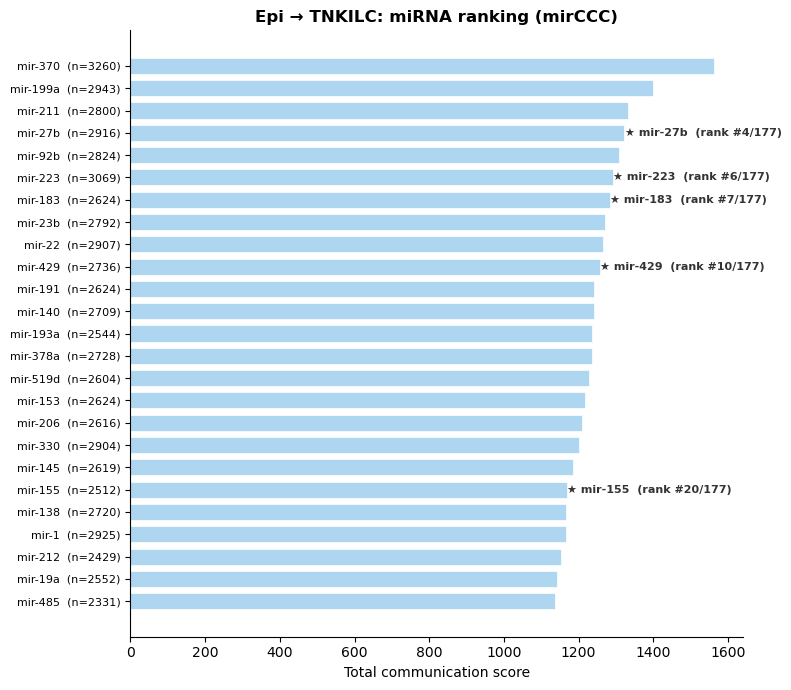

In [149]:
# miRNA ranking bar chart — per axis
from mirCCC_viz import plot_mirna_ranking

edge_df = results['mirna_edge_df']

# Strom → Epi axis
plot_mirna_ranking(
    edge_df, sender_type='Strom', receiver_type='Epi',
    focal_mirnas=['mir-200a', 'mir-204', 'mir-506', 'mir-34a', 'mir-214', 'mir-125a'],
    save_path=os.path.join(OUT_DIR, 'ranking_strom_epi.png')
)

# Myeloid → Epi axis
plot_mirna_ranking(
    edge_df, sender_type='Myeloid', receiver_type='Epi',
    focal_mirnas=['mir-200a', 'mir-204', 'mir-506', 'mir-34a', 'mir-214', 'mir-125a'],
    save_path=os.path.join(OUT_DIR, 'ranking_myeloid_epi.png')
)

# Epi → TNKILC axis
plot_mirna_ranking(
    edge_df, sender_type='Epi', receiver_type='TNKILC',
    focal_mirnas=['mir-155', 'mir-223', 'mir-27b', 'mir-183', 'mir-429'],
    save_path=os.path.join(OUT_DIR, 'ranking_epi_tnkilc.png')
)

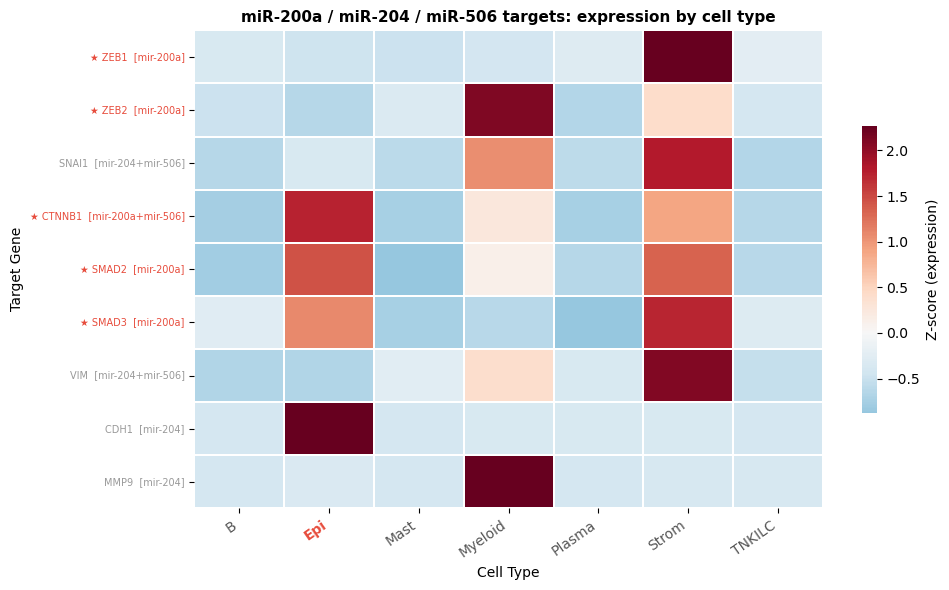

In [150]:
# Target gene expression heatmap
from mirCCC_viz import plot_target_heatmap, _norm_mir

mir2tar_df = pd.read_csv(STRONG_PATH)

# Top 3 Strom→Epi miRNAs and their targets
top_mirs = ['mir-200a', 'mir-204', 'mir-506']
top_norms = set(_norm_mir(m) for m in top_mirs)

mask = mir2tar_df['miRNA'].apply(lambda x: _norm_mir(str(x)) in top_norms)
all_targets = mir2tar_df.loc[mask, 'target_gene'].unique()
targets_in_data = [g for g in all_targets if g in adata.var_names]

# Build gene → miRNA mapping
gene_mirna_map = {}
for g in targets_in_data:
    targeting = set()
    for _, row in mir2tar_df[mask].iterrows():
        if row['target_gene'] == g:
            targeting.add(_norm_mir(str(row['miRNA'])))
    if targeting:
        gene_mirna_map[g] = targeting

# Select key EMT/TGF-β/Wnt target genes
key_genes = ['ZEB1', 'ZEB2', 'SNAI1', 'CTNNB1', 'SMAD2', 'SMAD3', 
             'VIM', 'CDH1', 'MMP9', 'TGFBR1', 'FN1', 'MMP2']
target_display = [g for g in key_genes if g in targets_in_data]

plot_target_heatmap(
    adata, target_genes=target_display,
    gene_mirna_map=gene_mirna_map,
    key_genes=['ZEB1', 'ZEB2', 'CTNNB1', 'SMAD2', 'SMAD3'],
    highlight_celltype='Epi',
    title='miR-200a / miR-204 / miR-506 targets: expression by cell type',
    save_path=os.path.join(OUT_DIR, 'target_heatmap_top3.png')
)